In [3]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from rich import print as rprint
#from rich.pretty import pprint
from pprint import pprint


In [4]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [5]:
model="deepseek-r1-distill-llama-70b"
llm=ChatGroq(model=model)
# response=llm.invoke("what is the capital of France")
# print(response.content)

In [6]:
from langchain_community.tools import TavilySearchResults
# search_tool=TavilySearchResults()
# search_tool.invoke("What is the capital of France?")


In [7]:
from langchain_core.tools import tool

In [8]:
@tool
def add(a:int,b:int):
    """"add"""
    c=a+b
    return f"the is {c}"
add(9,10)

/var/folders/4m/z36lvyp57r37vs_gdh88c2mc0000gn/T/ipykernel_71629/609338306.py:6: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  add(9,10)


AttributeError: 'int' object has no attribute 'parent_run_id'

In [9]:
@tool
def search(query:str):
    """Justa Tavily search"""
    tavily=TavilySearchResults()
    Result=tavily.invoke(query)
    return f"Result for {query} is : \n{Result}"

In [10]:
print(search.invoke({"query":"what is the capital of Switerland"}))

Result for what is the capital of Switerland is : 
[{'title': 'Capital of Switzerland: Why Bern Holds the Title', 'url': 'https://www.newlyswissed.com/capital-of-switzerland/', 'content': 'Quick FAQ: Switzerland’s Capital, Explained\n-------------------------------------------\n\nWhat is the capital of Switzerland?\n\nBern is the capital city in Switzerland, officially called the “federal city.”\n\nIt’s where the Swiss government and parliament meet, and it’s the heart of Swiss politics-even though it’s not the biggest city.\n\nWhy is Bern the capital and not Zurich?\n\nBern was picked in 1848 for its neutral, central location between language regions. [...] The capital of Switzerland is Bern, officially known as the “federal city.” Bern is home to the Swiss government and parliament, but it’s not the country’s largest city - that’s Zurich.\n\nThis fact surprises plenty of first-time visitors, especially those expecting Zurich or Geneva to hold the title. Bern is home to the Swiss gove

In [11]:
tools=[add,search]
tools

[StructuredTool(name='add', description='"add', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x11809f920>),
 StructuredTool(name='search', description='Justa Tavily search', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x1189d3ba0>)]

In [12]:
llm_with_tools=llm.bind_tools(tools)

In [13]:
result=llm_with_tools.invoke("what is the cureent GDP of INDIA")
result.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of India'},
  'id': '40hwrra3g',
  'type': 'tool_call'}]

In [14]:
tool_mapping={tool.name:tool for tool in tools}
tool_mapping

{'add': StructuredTool(name='add', description='"add', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x11809f920>),
 'search': StructuredTool(name='search', description='Justa Tavily search', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x1189d3ba0>)}

In [15]:
#manual Passing
tool_mapping["search"].invoke("what is capital of India")

'Result for what is capital of India is : \n[{\'title\': \'New Delhi - Wikipedia\', \'url\': \'https://en.wikipedia.org/wiki/New_Delhi\', \'content\': \'Appearance\\n\\nmove to sidebar hide\\n\\nCoordinates: 28°36′50″N 77°12′32″E / 28.61389°N 77.20889°E / 28.61389; 77.20889\\n\\nImage 4: Page semi-protected\\n\\nFrom Wikipedia, the free encyclopedia\\n\\nCapital city of India\\n\\nThis article is about the capital of India, within the union territory of Delhi. For other uses, see New Delhi (disambiguation) "New Delhi (disambiguation)"). [...] New Delhi (/ˈ nj uː ˈ d ɛ.l i/ⓘ;( _\\\\_\\\\\\\\_Naī Dillī\\\\\\\\_\\\\__, pronounced( "Help:IPA/Hindi and Urdu")) is the capital of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the Government of India, hosting the Rashtrapati Bhavan, Sansad Bhavan, and the Supreme Court. New Delhi is a municipality within the NCT, administered by the New Delhi Municipal Council (NDMC), which cov

In [16]:
tool_mapping[result.tool_calls[0]["name"]].invoke("what is GDP OF INDIA")

'Result for what is GDP OF INDIA is : \n[{\'title\': \'India GDP 2025 - StatisticsTimes.com\', \'url\': \'https://www.statisticstimes.com/economy/country/india-gdp.php\', \'content\': "According to the IMF World Economic Outlook (October 2024), India\'s nominal GDP in 2025 is projected at $4,272 billion at current prices. India is the 5th largest economy globally. India attained the highest 5th rank in 2021 and the lowest 17th in 1991. India contributes 3.70% of the entire world\'s GDP. India\'s share of the world economy increased from 1.08 percent in 1993 to the current estimate of 3.70 percent in 2025. [...] Based on PPP, India\'s economy in 2025 is projected at 17,365 billion international dollars, 3rd highest in the world, behind the United States and China. India contributes 8.49% of the entire world\'s GDP (PPP). India shares almost 17.4 percent of the total of Asia\'s GDP (PPP). The gross domestic product (GDP) of India at purchasing power parity (PPP) is 4.07 times the GDP at 

In [17]:
from langchain_core.messages import BaseMessage
from typing import Literal
import operator
from pydantic import BaseModel,Field
from typing import TypedDict, Annotated, Sequence
from langchain.prompts import ChatPromptTemplate,PromptTemplate

from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage,AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain import hub
#we need to mention litterals for type hinting

from typing import Literal

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [18]:
def invoke_model(state:AgentState):
    messages=state["messages"]
    question=messages[-1]
    result=llm_with_tools.invoke(question)
    return{"messages":[result]}

In [19]:
def router(state:AgentState):
    tool_calls=state["messages"][-1].tool_calls
    if len(tool_calls)>0:
        return "tool"
    else:
        return "end"

In [20]:
def invoke_tool(state:AgentState):
    tool_details=state["messages"][-1].tool_calls
    
    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    
    print(f"Seleted tool: {tool_details[0]['name']}")
    
    if tool_details[0]["name"]=="search":
        response1=input(prompt=f"[yes/no] do you want to continue with this expensive web search")
        if response1.lower()=="no":
            print("web search discarded by the user. exiting gracefully")
            raise Exception("Web search discarded by the user.")
            
    
    response2=tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {"messages":[response2]}
            

In [21]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(AgentState)

In [22]:
graph.add_node("ai_assistant",invoke_model)
graph.add_node("tool",invoke_tool)


In [23]:
graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool":"tool",
                                "end":END
                            })

In [24]:
graph.add_edge("tool",END)

graph.set_entry_point("ai_assistant")

In [25]:
app=graph.compile()

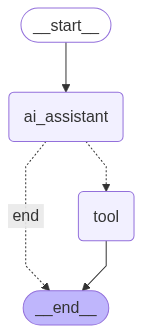

In [26]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
#it will be promptng at the top for yes/no
output=app.invoke({"messages":["What is the current gdp of the india?"]})


Seleted tool: search


In [28]:
from pprint import pprint
from rich import print as rprint
final_content = output["messages"][-1]
rprint(final_content)

Result for current GDP of India is : 
[{'title': 'India - GDP, PPP (current International $) - 2025 Data 2026 Forecast ...', 'url': 
'https://tradingeconomics.com/india/gdp-ppp-us-dollar-wb-data.html', 'content': 'GDP, PPP (current international $)
in India was reported at 14619765554295 USD in 2023, according to the World Bank collection of development 
indicators, compiled from officially recognized sources. India - GDP, PPP (current international $) - actual 
values, historical data, forecasts and projections were sourced from the World Bank on June of 2025.', 'score': 
0.8800674}, {'title': 'World GDP Ranking 2025 List - ClearTax', 'url': 
'https://cleartax.in/s/world-gdp-ranking-list', 'content': "India is currently ranked as the 4th largest economy 
globally in 2025, surpassing Japan to secure the 4th position among the world's top 10 largest economies, with a 
nominal GDP of $4.19 trillion in 2025. Moreover, the IMF forecasts that by 2027, India will overtake Germany to 
become the 3rd largest economy worldwide [...] With an estimated real GDP of Rs. 187.95 lakh crore in 2024-25, 
against the real GDP of Rs. 176.51 in 2023-24 generated by a population of over 1 billion, India is among the 
highest population-based economies in the world. Additionally, as per IMF projections, India's GDP grow is at 6.2% 
in 2024-25 and 2025-26.This means India's economic growth next fiscal year will be the fastest among major 
economies. Therefore, in the upcoming years, rising consumption and investments, both domestic and [...] ## India 
GDP Per Capita 2025 / India Per Capita Income 2025\n\nThough India's rank in the World GDP Ranking 2025 list is 
fifth, the per capita income is substantially low. India's per capita income of the population for 2025 is $2,880 
(Approx Rs.2.4 lakh). Multiple factors have led to low per capita income in India compared to the top GDP 
countries.", 'score': 0.850382}, {'title': 'India GDP PPP 2024 Estimate and 2025 Projection - World Economics', 
'url': 'https://www.worldeconomics.com/GrossDomesticProduct/Real-GDP-PPP/India.aspx', 'content': "India GDP: 
$14.018 Trillion\u200b\u200b Looking ahead to 2025, projections suggest India's 2025 GDP estimate could be $14.929 
Trillion. This India GDP growth forecast for", 'score': 0.82082915}, {'title': "Is India the world's fourth largest
economy? - The Hindu", 'url': 
'https://www.thehindu.com/business/Economy/is-india-the-worlds-fourth-largest-economy/article69645115.ece', 
'content': "As per these projections, India's GDP in 2025 was likely to be $4,187.03 billion, which will be 
marginally higher than the GDP of Japan at $4,", 'score': 0.77994305}, {'title': 'Economic Survey 2025: India GDP 
Growth Rate Forecast and Projections ...', 'url': 
'https://indianexpress.com/article/business/economic-survey-india-gdp-9809620/', 'content': "Economic Survey 2025 
India's GDP Growth Rate: Meanwhile, India's GDP is projected to grow at a 4-year low pace of 6.4 per cent in the 
current fiscal on weak manufacturing and investments.", 'score': 0.77179235}]

Langgraph inbuilt human in loop

In [29]:
from langgraph.prebuilt import ToolNode,tools_condition
tool_node=ToolNode(tools)

In [30]:
def ai_assistant(state:AgentState):
    response=llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

In [31]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [32]:
graph_builder=StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)
graph_builder.add_node("tools", tool_node)


graph_builder.add_edge(START,"ai_assistant")
graph_builder.add_conditional_edges("ai_assistant",
                                    tools_condition,
                                    )
graph_builder.add_edge("tools", "ai_assistant")


In [33]:
app2=graph_builder.compile(checkpointer=memory,interrupt_before=["tools"])

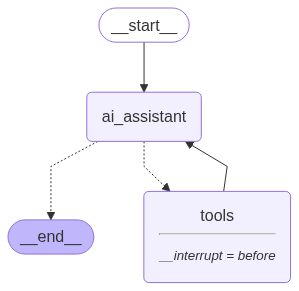

In [34]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [35]:
config={"configurable":{"thread_id":"1"}}
config

{'configurable': {'thread_id': '1'}}

In [36]:
from langchain_core.messages import HumanMessage
response=app2.invoke({"messages":[HumanMessage("What is the current gdp of the china?")]},config=config)

In [37]:
pprint(response)


{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
              AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zs9kdw6g9', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 248, 'prompt_tokens': 170, 'total_tokens': 418, 'completion_time': 1.1561601559999999, 'prompt_time': 0.018139841, 'queue_time': 0.05375451299999999, 'total_time': 1.174299997}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--28ce71b4-8601-44fd-bd59-f9d8cef6b67f-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'zs9kdw6g9', 'type': 'tool_call'}], usage_metadata={'input_tokens': 170, 'output_tokens': 248, 'total_tokens': 418})]}


In [38]:

snapshot=app2.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zs9kdw6g9', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 248, 'prompt_tokens': 170, 'total_tokens': 418, 'completion_time': 1.1561601559999999, 'prompt_time': 0.018139841, 'queue_time': 0.05375451299999999, 'total_time': 1.174299997}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--28ce71b4-8601-44fd-bd59-f9d8cef6b67f-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'zs9kdw6g9', 'type': 'tool_call'}], usage_metadata={'input_tokens': 170, 'output_tokens': 248, 'total_tokens': 418})]}, next=('tools',), config={'configurable': {'thread_id': '1'

In [39]:
snapshot.next

('tools',)

In [40]:
last_message=snapshot.values["messages"][-1]
tool_details=last_message.tool_calls

In [41]:
if tool_details[0]["name"]== "search":
    user_input=input(prompt=f"[yes/no] do you want to continue with {tool_details[0]['name']}?").lower()
    if user_input=="no":
        print("web tool discarded")
        raise Exception("Web tool discarded by the user.")
    else:
        response=app2.invoke(None,config)
        rprint(response)
else:
    response=app2.invoke(None,config)
    rprint(response)

{
    'messages': [
        HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'zs9kdw6g9',
                        'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 248,
                    'prompt_tokens': 170,
                    'total_tokens': 418,
                    'completion_time': 1.1561601559999999,
                    'prompt_time': 0.018139841,
                    'queue_time': 0.05375451299999999,
                    'total_time': 1.174299997
                },
                'model_name': 'deepseek-r1-distill-llama-70b',
                'system_fingerprint': 'fp_1bbe7845ec',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='run--28ce71b4-8601-44fd-bd59-f9d8cef6b67f-0',
            tool_calls=[
                {
                    'name': 'search',
                    'args': {'query': 'current GDP of China'},
                    'id': 'zs9kdw6g9',
                    'type': 'tool_call'
                }
            ],
            usage_metadata={'input_tokens': 170, 'output_tokens': 248, 'total_tokens': 418}
        ),
        ToolMessage(
            content="Result for current GDP of China is : \n[{'title': 'China GDP - Worldometer', 'url': 
'https://www.worldometers.info/gdp/china-gdp/', 'content': 'Nominal (current) Gross Domestic Product (GDP) of China
is $17,794,800,000,000 (USD) as of 2023. · Real GDP (constant, inflation adjusted) of China reached', 'score': 
0.92507464}, {'title': 'China: GDP at current prices 1985-2030 - Statista', 'url': 
'https://www.statista.com/statistics/263770/gross-domestic-product-gdp-of-china/', 'content': 'In 2024, the gross 
domestic product (GDP) of China amounted to around 18.7 trillion U.S. dollars. In comparison to the GDP of the 
other BRIC', 'score': 0.87113565}, {'title': 'China GDP - Trading Economics', 'url': 
'https://tradingeconomics.com/china/gdp', 'content': '##### Members\\n\\n##### \\n\\n# China GDP\\n\\n## The Gross 
Domestic Product (GDP) in China was worth 17794.78 billion US dollars in 2023, according to official data from the 
World Bank. The GDP value of China represents 16.88 percent of the world economy. source: World Bank [...] ### GDP 
in China is expected to reach 18542.00 USD Billion by the end of 2025, according to Trading Economics global macro 
models and analysts expectations. In the long-term, the China GDP is projected to trend around 19284.00 USD Billion
in 2026 and 20094.00 USD Billion in 2027, according to our econometric models. [...] ## GDP in China averaged 
3291.24 USD Billion from 1960 until 2023, reaching an all time high of 17881.78 USD Billion in 2022 and a record 
low of 47.21 USD Billion in 1962. This page provides - China GDP - actual values, historical data, forecast, chart,
statistics, economic calendar and news. China GDP - values, historical data and charts - was last updated on June 
of 2025.', 'score': 0.8690161}, {'title': 'China GDP | Historical Chart & Data - Macrotrends', 'url': 
'https://www.macrotrends.net/global-metrics/countries/chn/china/gdp-gross-domestic-product', 'content': 'China GDP 
for 2023 was 17.795 trillion US dollars, a 0.49% decline from 2022. · China GDP for 2022 was 17.882 trillion US 
dollars, a 0.34% increase from 2021.', 'score': 0.8282873}, {'title': 'National Bureau of Statistics of China - 
National Data', 'url': 'https://data.stats.gov.cn/english/easyquery.htm?cn=B01', 'content': '4Q 2023 ; Gross 
Domestic Product, Current Quarter(100 million yuan), 318758.0, 373726.2, 341758.0, 328837.6 

In [46]:
state.next()

NameError: name 'state' is not defined